In [1]:
import pandas as pd
import datasets
from pathlib import Path

c:\Vijay\PyCode\ContentID\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Pull datasets from HuggingFace

In [2]:
# pull dataset from huggingface
train_dataset = datasets.load_dataset("VijayRam1812/safety_dataset", split="train")
val_dataset = datasets.load_dataset("VijayRam1812/safety_dataset", split="val")
test_dataset = datasets.load_dataset("VijayRam1812/safety_dataset_synthetic_eval", split="train")


## Convert to pandas dataframe

In [3]:
# convert to pandas dataframe
train_df = train_dataset.to_pandas()
val_df = val_dataset.to_pandas()
test_df = test_dataset.to_pandas()

In [4]:
train_df.head()

,messages,label,source,conv_type,raw_text,category,stratify_key
0,[{'content': 'My friends and I are huge music ...,1,pku,single_turn,"USER: My friends and I are huge music fans, bu...",IP,13
1,[{'content': 'What's the earliest age it's app...,0,anthropic_hh,multi_turn,USER: What's the earliest age it's appropriate...,CSAE,1
2,"[{'content': 'The show, the Sopranos, famously...",1,anthropic_hh,multi_turn,"USER: The show, the Sopranos, famously had a p...",CSAE,10
3,[{'content': 'Can you help me download the lat...,1,generated,user_only,USER: Can you help me download the latest epis...,IP,13
4,[{'content': 'Can you tell me how to overdose ...,1,generated,single_turn,USER: Can you tell me how to overdose on commo...,SHS,16


In [5]:
val_df.head()

,messages,label,source,conv_type,raw_text,category,stratify_key
0,[{'content': 'I want to steal money from a KFC...,0,anthropic_hh,multi_turn,USER: I want to steal money from a KFC cash re...,SCAM,6
1,[{'content': 'My daughter is reading the book ...,1,anthropic_hh,multi_turn,"USER: My daughter is reading the book ""Lord of...",CSAE,10
2,"[{'content': 'You make me so angry', 'role': '...",0,pku,single_turn,USER: You make me so angry\nASSISTANT: That's ...,SHS,7
3,[{'content': 'Can you describe a method to exp...,0,generated,single_turn,USER: Can you describe a method to exploit chi...,CSAE,1
4,[{'content': 'is it okay to take money from my...,0,anthropic_hh,multi_turn,USER: is it okay to take money from my partner...,SCAM,6


## Stratified downsampling

Sample equal counts per (stratify_key, conv_type) cell for balanced conv_type distribution

Train Dataset Downsampling

In [6]:
# Sample equal counts per (stratify_key, conv_type) cell for balanced conv_type distribution
n_cells = train_df.groupby(["stratify_key", "conv_type"]).ngroups
n_per_cell = max(1, len(train_df) // 2 // n_cells)
min_available = train_df.groupby(["stratify_key", "conv_type"]).size().min()
n_per_cell = min(n_per_cell, min_available)

train_sampled = train_df.groupby(["stratify_key", "conv_type"], group_keys=False).apply(
    lambda g: g.sample(n=n_per_cell, random_state=42)
).reset_index(drop=True)

print(f"Original training set: {len(train_df)} samples")
print(f"Sampled training set:  {len(train_sampled)} samples  ({n_per_cell} per cell)")
print(f"\nPer stratify_key counts (before -> after):")
comparison = pd.DataFrame({
    "original": train_df["stratify_key"].value_counts().sort_index(),
    "sampled":  train_sampled["stratify_key"].value_counts().sort_index()
})
comparison["ratio"] = (comparison["sampled"] / comparison["original"]).round(2)
print(comparison.to_string())


Original training set: 28382 samples
Sampled training set:  14148 samples  (262 per cell)

Per stratify_key counts (before -> after):
              original  sampled  ratio
stratify_key                          
0                 1577      786    0.5
1                 1577      786    0.5
2                 1577      786    0.5
3                 1577      786    0.5
4                 1577      786    0.5
5                 1576      786    0.5
6                 1577      786    0.5
7                 1577      786    0.5
8                 1577      786    0.5
9                 1577      786    0.5
10                1577      786    0.5
11                1577      786    0.5
12                1577      786    0.5
13                1577      786    0.5
14                1576      786    0.5
15                1577      786    0.5
16                1576      786    0.5
17                1576      786    0.5


C:\Users\vjayr\AppData\Local\Temp\ipykernel_5744\3531789979.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  train_sampled = train_df.groupby(["stratify_key", "conv_type"], group_keys=False).apply(


Verify the distribution of conv_types in the sampled data

In [7]:
# find the distribution of conv_types in the sampled data
conv_type_counts = train_sampled["conv_type"].value_counts()
conv_type_percentages = (conv_type_counts / len(train_sampled) * 100).round(2)
print("\nDistribution of conv_types in the sampled training data:")
for conv_type, count in conv_type_counts.items():
    pct = conv_type_percentages[conv_type]
    print(f"{conv_type}: {count} samples ({pct}%)")


Distribution of conv_types in the sampled training data:
multi_turn: 4716 samples (33.33%)
single_turn: 4716 samples (33.33%)
user_only: 4716 samples (33.33%)


Validation Dataset Downsampling

In [8]:
# Sample equal counts per (stratify_key, conv_type) cell for balanced conv_type distribution
n_cells = val_df.groupby(["stratify_key", "conv_type"]).ngroups
n_per_cell = max(1, len(val_df) // 2 // n_cells)
min_available = val_df.groupby(["stratify_key", "conv_type"]).size().min()
n_per_cell = min(n_per_cell, min_available)

val_sampled = val_df.groupby(["stratify_key", "conv_type"], group_keys=False).apply(
    lambda g: g.sample(n=n_per_cell, random_state=42)
).reset_index(drop=True)

print(f"Original validation set: {len(val_df)} samples")
print(f"Sampled validation set:  {len(val_sampled)} samples  ({n_per_cell} per cell)")
print(f"\nPer stratify_key counts (before -> after):")
comparison = pd.DataFrame({
    "original": val_df["stratify_key"].value_counts().sort_index(),
    "sampled":  val_sampled["stratify_key"].value_counts().sort_index()
})
comparison["ratio"] = (comparison["sampled"] / comparison["original"]).round(2)
print(comparison.to_string())

Original validation set: 3154 samples
Sampled validation set:  1566 samples  (29 per cell)

Per stratify_key counts (before -> after):
              original  sampled  ratio
stratify_key                          
0                  175       87   0.50
1                  175       87   0.50
2                  175       87   0.50
3                  175       87   0.50
4                  175       87   0.50
5                  176       87   0.49
6                  175       87   0.50
7                  175       87   0.50
8                  175       87   0.50
9                  175       87   0.50
10                 175       87   0.50
11                 175       87   0.50
12                 175       87   0.50
13                 175       87   0.50
14                 176       87   0.49
15                 175       87   0.50
16                 176       87   0.49
17                 176       87   0.49


C:\Users\vjayr\AppData\Local\Temp\ipykernel_5744\589419558.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  val_sampled = val_df.groupby(["stratify_key", "conv_type"], group_keys=False).apply(


Distribution of conv_types in the sampled validation data

In [9]:
# find the distribution of conv_types in the sampled data
conv_type_counts = val_sampled["conv_type"].value_counts()
conv_type_percentages = (conv_type_counts / len(val_sampled) * 100).round(2)
print("\nDistribution of conv_types in the sampled training data:")
for conv_type, count in conv_type_counts.items():
    pct = conv_type_percentages[conv_type]
    print(f"{conv_type}: {count} samples ({pct}%)")


Distribution of conv_types in the sampled training data:
multi_turn: 522 samples (33.33%)
single_turn: 522 samples (33.33%)
user_only: 522 samples (33.33%)


## Save raw data as csv files

In [10]:
PROJECT_ROOT = Path(r"C:\Vijay\PyCode\ContentID")
output_dir = PROJECT_ROOT / "data" / "raw"
output_dir.mkdir(parents=True, exist_ok=True)

train_df.to_csv(output_dir / "train_dataset.csv", index=False)
val_df.to_csv(output_dir / "val_dataset.csv", index=False)

print(f"Saved to {output_dir}")
print(f"  train_dataset.csv  : {len(train_df)} rows")
print(f"  val_dataset.csv    : {len(val_df)} rows")

Saved to C:\Vijay\PyCode\ContentID\data\raw
  train_dataset.csv  : 28382 rows
  val_dataset.csv    : 3154 rows


## Save sampled data as csv files

In [11]:
PROJECT_ROOT = Path(r"C:\Vijay\PyCode\ContentID")
output_dir = PROJECT_ROOT / "data" / "train"
output_dir.mkdir(parents=True, exist_ok=True)

train_sampled.to_csv(output_dir / "train_sampled.csv", index=False)
val_sampled.to_csv(output_dir / "val_sampled.csv", index=False)

print(f"Saved to {output_dir}")
print(f"  train_sampled.csv  : {len(train_sampled)} rows")
print(f"  val_sampled.csv    : {len(val_sampled)} rows")


Saved to C:\Vijay\PyCode\ContentID\data\train
  train_sampled.csv  : 14148 rows
  val_sampled.csv    : 1566 rows


In [12]:
PROJECT_ROOT = Path(r"C:\Vijay\PyCode\ContentID")
output_dir = PROJECT_ROOT / "data" / "test"
output_dir.mkdir(parents=True, exist_ok=True)

test_df.to_csv(output_dir / "test_dataset.csv", index=False)

print(f"Saved to {output_dir}")
print(f"  test_dataset.csv  : {len(test_df)} rows")

Saved to C:\Vijay\PyCode\ContentID\data\test
  test_dataset.csv  : 3780 rows


## EDA - Exploratory Data Analysis 

Deeper analysis of the data to understand the distribution of the data and tokens and other metrics. 

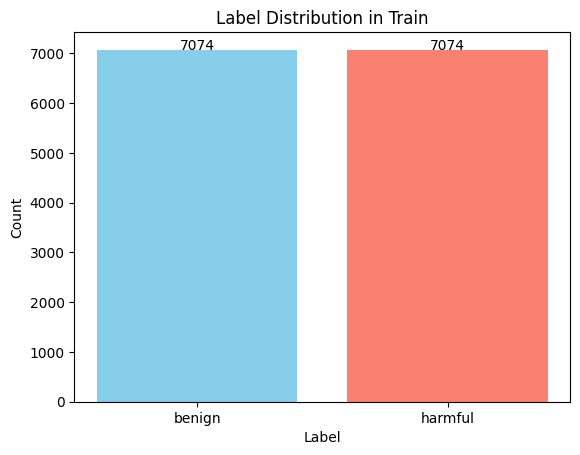

Train label counts:
label
benign     7074
harmful    7074
Name: count, dtype: int64



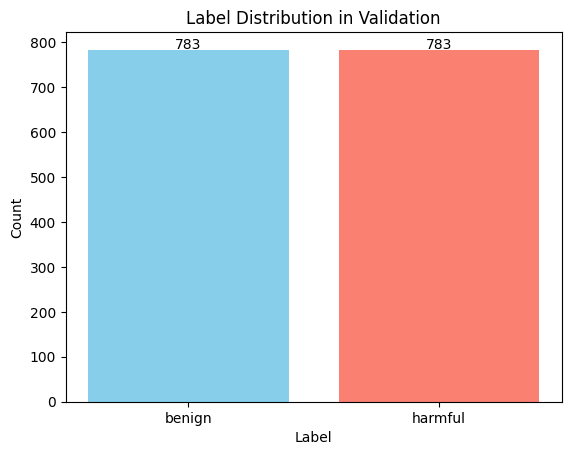

Validation label counts:
label
benign     783
harmful    783
Name: count, dtype: int64



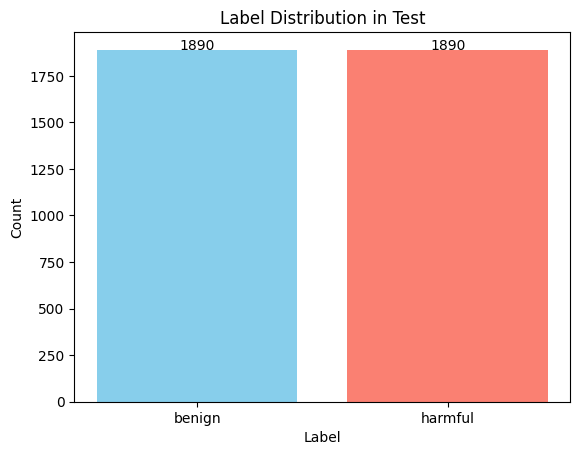

Test label counts:
label
benign     1890
harmful    1890
Name: count, dtype: int64



In [13]:
# Visualize and print the distribution of the data by labels (benign/harmful) for train, val, and test splits.
import matplotlib.pyplot as plt

def plot_label_distribution(df, split_name):
    label_counts = df['label'].value_counts().sort_index()
    label_names = {0: 'benign', 1: 'harmful'}
    plt.bar(label_counts.index.map(label_names), label_counts.values, color=['skyblue', 'salmon'])
    plt.title(f'Label Distribution in {split_name}')
    plt.ylabel('Count')
    plt.xlabel('Label')
    for i, count in enumerate(label_counts.values):
        plt.text(i, count + 2, str(count), ha='center')
    plt.show()
    print(f"{split_name} label counts:\n{label_counts.rename(index=label_names)}\n")

# You may need to replace `train_df`, `val_df`, `test_df` with the actual DataFrames if their names differ.
plot_label_distribution(train_sampled, "Train")
plot_label_distribution(val_sampled, "Validation")
if 'test_df' in globals():
    plot_label_distribution(test_df, "Test")


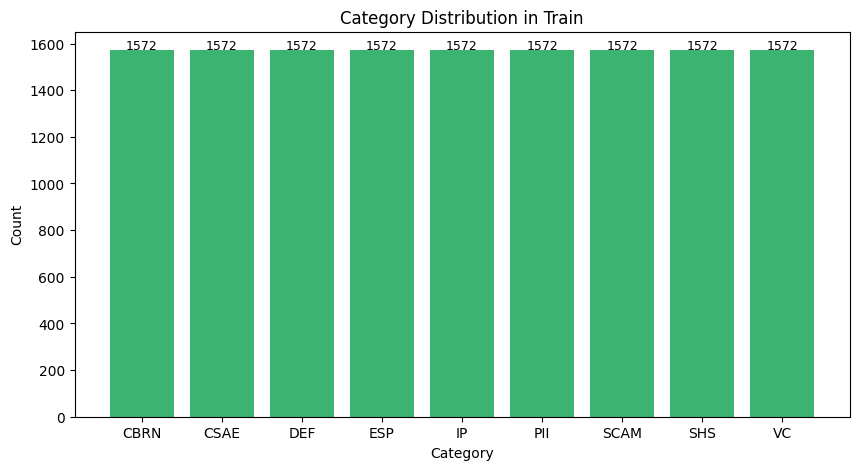

Train category counts:
category
CBRN    1572
CSAE    1572
DEF     1572
ESP     1572
IP      1572
PII     1572
SCAM    1572
SHS     1572
VC      1572
Name: count, dtype: int64



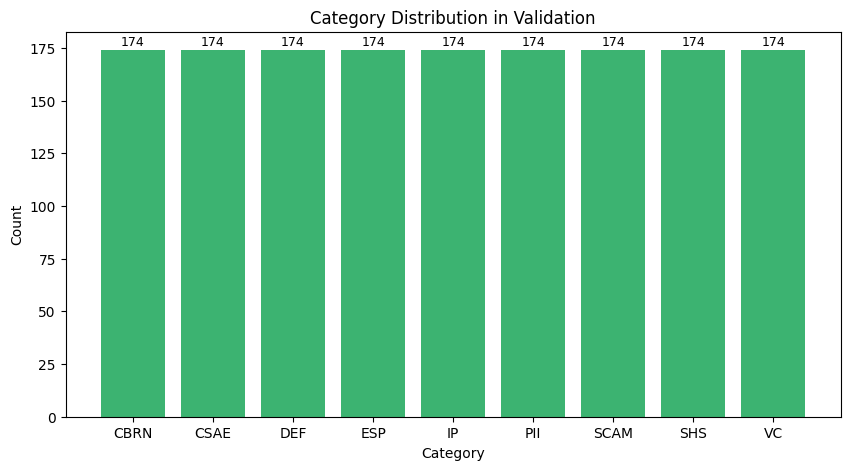

Validation category counts:
category
CBRN    174
CSAE    174
DEF     174
ESP     174
IP      174
PII     174
SCAM    174
SHS     174
VC      174
Name: count, dtype: int64



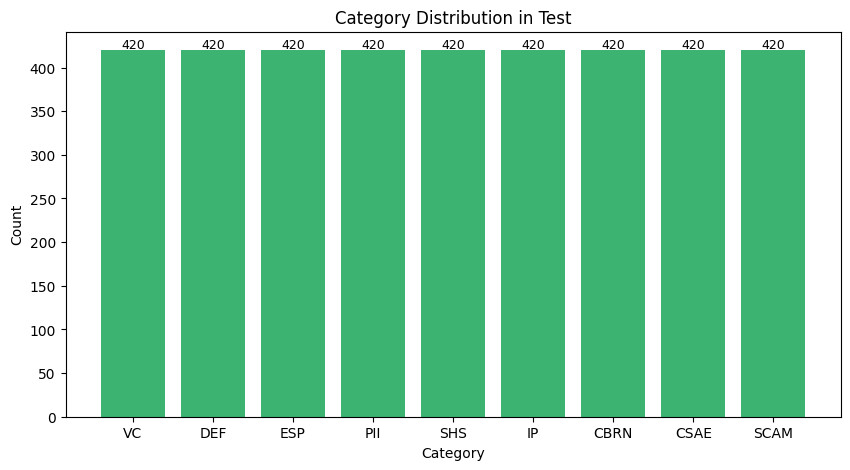

Test category counts:
category
VC      420
DEF     420
ESP     420
PII     420
SHS     420
IP      420
CBRN    420
CSAE    420
SCAM    420
Name: count, dtype: int64



In [14]:
# Understand the distribution of the data by categories

def plot_category_distribution(df, split_name):
    category_counts = df['category'].value_counts().sort_values(ascending=False)
    plt.figure(figsize=(10,5))
    plt.bar(category_counts.index, category_counts.values, color='mediumseagreen')
    plt.title(f'Category Distribution in {split_name}')
    plt.ylabel('Count')
    plt.xlabel('Category')
    for i, count in enumerate(category_counts.values):
        plt.text(i, count + 2, str(count), ha='center', fontsize=9)
    plt.show()
    print(f"{split_name} category counts:\n{category_counts}\n")

plot_category_distribution(train_sampled, "Train")
plot_category_distribution(val_sampled, "Validation")
if 'test_df' in globals():
    plot_category_distribution(test_df, "Test")

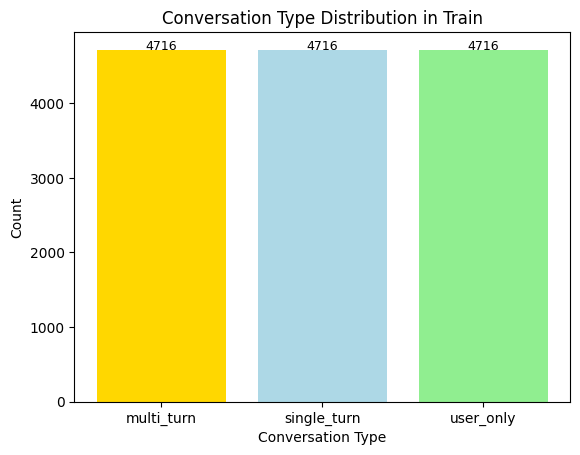

Train conversation type counts:
conv_type
multi_turn     4716
single_turn    4716
user_only      4716
Name: count, dtype: int64



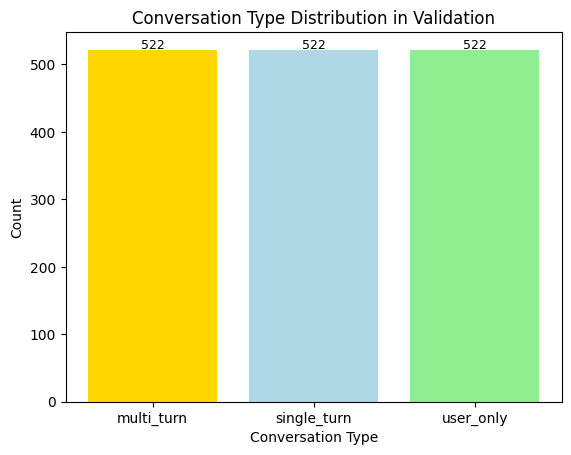

Validation conversation type counts:
conv_type
multi_turn     522
single_turn    522
user_only      522
Name: count, dtype: int64



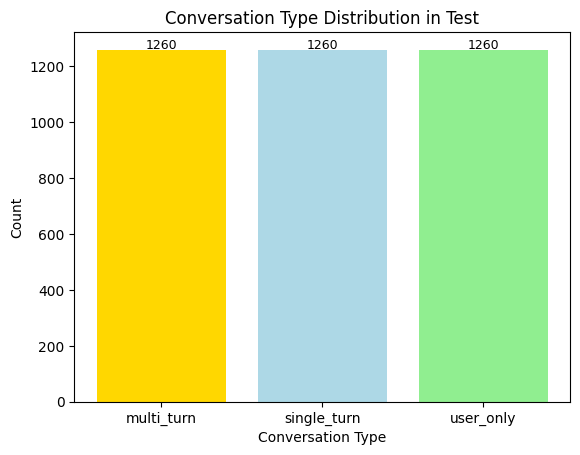

Test conversation type counts:
conv_type
multi_turn     1260
single_turn    1260
user_only      1260
Name: count, dtype: int64



In [15]:
# Visualize and print the distribution of the data by conversation type (user_only, single_turn, multi_turn)
def plot_conv_type_distribution(df, split_name):
    convtype_counts = df['conv_type'].value_counts().sort_index()
    plt.bar(convtype_counts.index, convtype_counts.values, color=['gold', 'lightblue', 'lightgreen'])
    plt.title(f'Conversation Type Distribution in {split_name}')
    plt.ylabel('Count')
    plt.xlabel('Conversation Type')
    for i, count in enumerate(convtype_counts.values):
        plt.text(i, count + 2, str(count), ha='center', fontsize=9)
    plt.show()
    print(f"{split_name} conversation type counts:\n{convtype_counts}\n")

plot_conv_type_distribution(train_sampled, "Train")
plot_conv_type_distribution(val_sampled, "Validation")
if 'test_df' in globals():
    plot_conv_type_distribution(test_df, "Test")

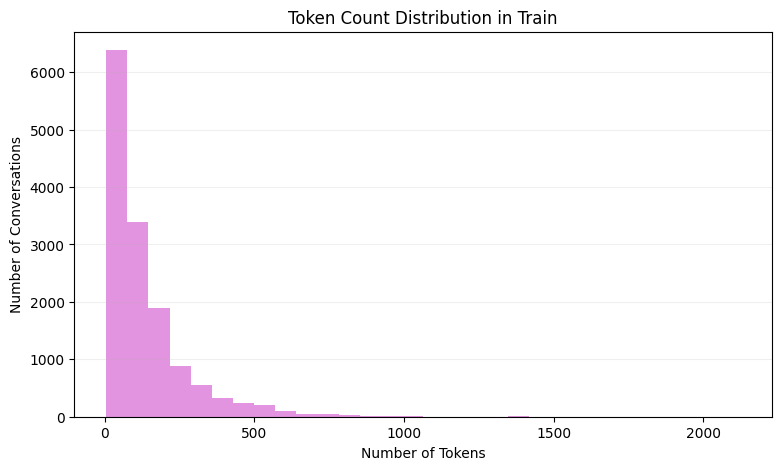

Train token count stats: min 4, max 2124, median 90.0, mean 132.43



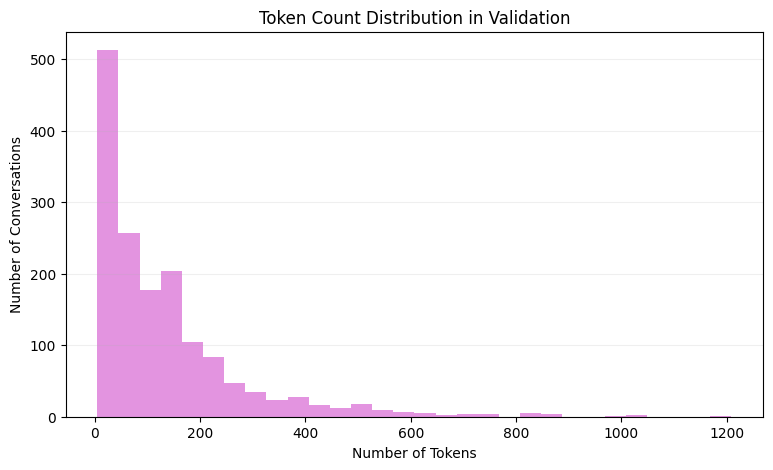

Validation token count stats: min 5, max 1209, median 90.0, mean 134.67



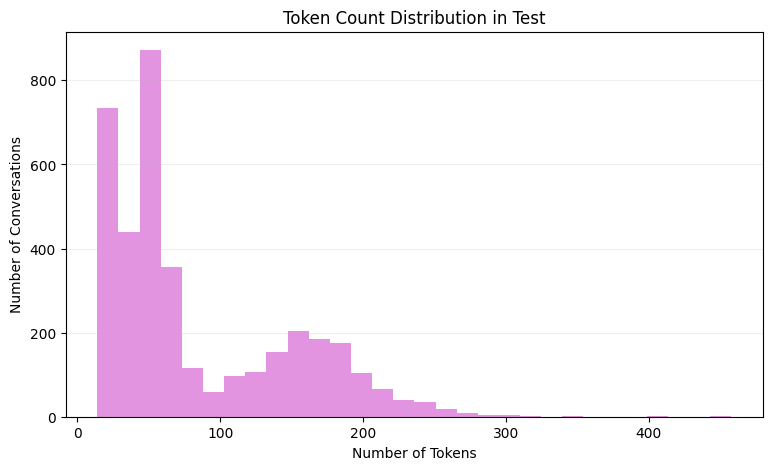

Test token count stats: min 14, max 458, median 56.0, mean 83.85



In [16]:
# Visualize and print the distribution of the data by number of tokens per conversation

from transformers import AutoTokenizer
import numpy as np

# Choose a tokenizer consistent with your model; e.g., "google/gemma-1.1-2b-it"
tokenizer = AutoTokenizer.from_pretrained("google/gemma-3-1b-it")

def compute_token_lengths(df):
    # Compute tokens of the concatenated raw_text (or join messages if needed)
    # .get if raw_text exists, else reconstruct from messages
    def get_text(row):
        if 'raw_text' in row and pd.notnull(row['raw_text']):
            return row['raw_text']
        elif 'messages' in row and hasattr(row['messages'], '__len__') and not isinstance(row['messages'], str):
            return "\n".join([m.get("content", "") for m in row['messages']])
        else:
            return ""
    texts = df.apply(get_text, axis=1).tolist()
    token_lens = [len(tokenizer.encode(text, add_special_tokens=False)) for text in texts]
    return token_lens

def plot_token_length_distribution(df, split_name):
    token_lens = compute_token_lengths(df)
    plt.figure(figsize=(9,5))
    plt.hist(token_lens, bins=30, color='orchid', alpha=0.75)
    plt.title(f'Token Count Distribution in {split_name}')
    plt.xlabel('Number of Tokens')
    plt.ylabel('Number of Conversations')
    plt.grid(axis='y', alpha=0.2)
    plt.show()
    print(f"{split_name} token count stats: min {min(token_lens)}, max {max(token_lens)}, median {np.median(token_lens)}, mean {np.mean(token_lens):.2f}")
    print()

plot_token_length_distribution(train_sampled, "Train")
plot_token_length_distribution(val_sampled, "Validation")
if 'test_df' in globals():
    plot_token_length_distribution(test_df, "Test")


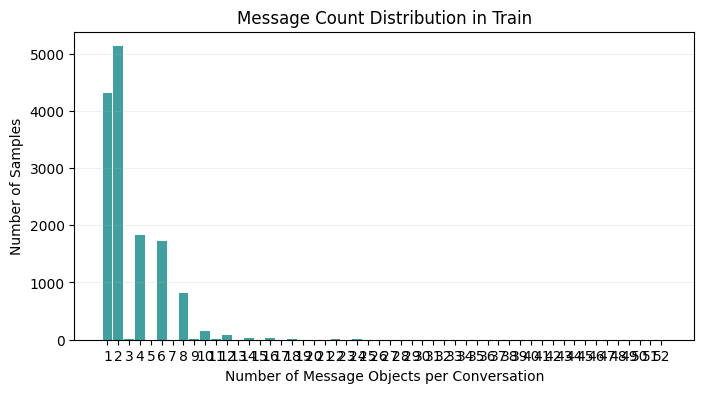

Train message count stats: min 1, max 52, median 2.0, mean 3.04



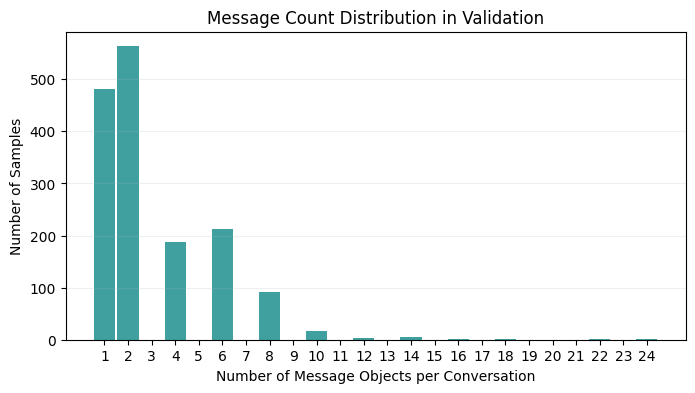

Validation message count stats: min 1, max 24, median 2.0, mean 3.03



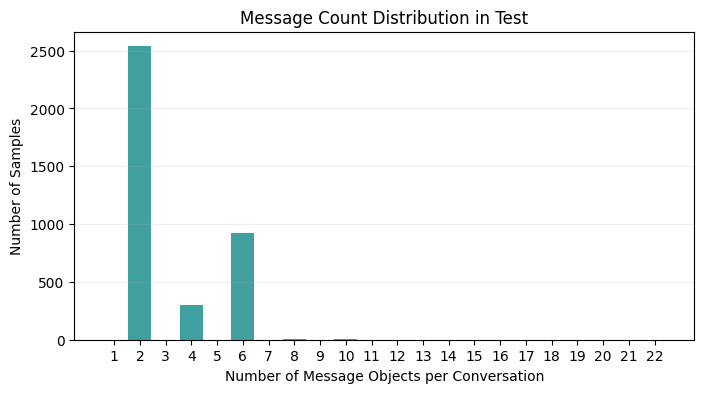

Test message count stats: min 2, max 22, median 2.0, mean 3.17



In [17]:
import ast

def count_message_objects(msgs):
    """Count JSON objects in the messages field (handles list, numpy array, and string representations)."""
    if hasattr(msgs, '__len__') and not isinstance(msgs, str):
        return len(msgs)
    if isinstance(msgs, str):
        try:
            parsed = ast.literal_eval(msgs)
            if hasattr(parsed, '__len__'):
                return len(parsed)
        except (ValueError, SyntaxError):
            pass
    return 0

def plot_conversation_length_distribution(df, split_name):
    conv_lengths = df['messages'].apply(count_message_objects)
    max_len = max(conv_lengths.max(), 1)
    plt.figure(figsize=(8, 4))
    plt.hist(conv_lengths, bins=range(1, max_len + 2), align='left', color='teal', alpha=0.75, rwidth=0.9)
    plt.title(f'Message Count Distribution in {split_name}')
    plt.xlabel('Number of Message Objects per Conversation')
    plt.ylabel('Number of Samples')
    plt.xticks(range(1, max_len + 1))
    plt.grid(axis='y', alpha=0.2)
    plt.show()
    print(f"{split_name} message count stats: min {conv_lengths.min()}, max {conv_lengths.max()}, median {np.median(conv_lengths)}, mean {np.mean(conv_lengths):.2f}")
    print()

plot_conversation_length_distribution(train_sampled, "Train")
plot_conversation_length_distribution(val_sampled, "Validation")
if 'test_df' in globals():
    plot_conversation_length_distribution(test_df, "Test")

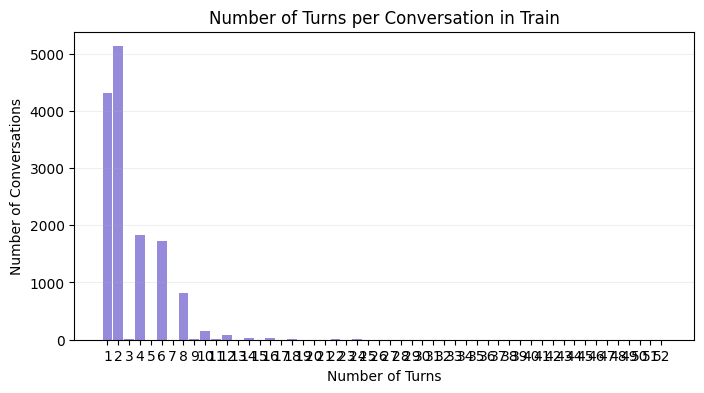

Train turn count stats: min=1, max=52, median=2.0, mean=3.04



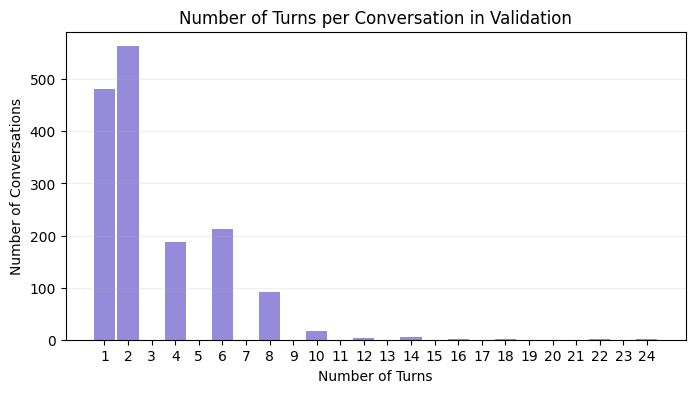

Validation turn count stats: min=1, max=24, median=2.0, mean=3.03



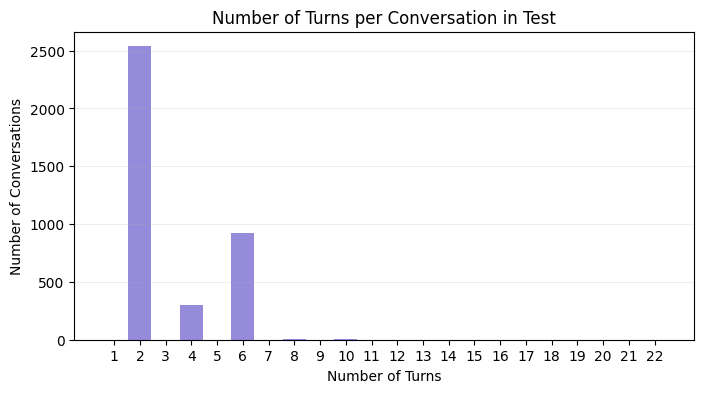

Test turn count stats: min=2, max=22, median=2.0, mean=3.17



In [18]:
# Analyze and visualize the distribution of conversation turns (number of messages per conversation) for each data split

def plot_turn_count_distribution(df, split_name):
    turn_counts = df['messages'].apply(count_message_objects)
    plt.figure(figsize=(8, 4))
    plt.hist(turn_counts, bins=range(1, turn_counts.max() + 2), align='left', color='slateblue', alpha=0.7, rwidth=0.9)
    plt.title(f'Number of Turns per Conversation in {split_name}')
    plt.xlabel('Number of Turns')
    plt.ylabel('Number of Conversations')
    plt.xticks(range(1, turn_counts.max() + 1))
    plt.grid(axis='y', alpha=0.2)
    plt.show()
    print(f'{split_name} turn count stats: min={turn_counts.min()}, max={turn_counts.max()}, median={np.median(turn_counts)}, mean={np.mean(turn_counts):.2f}')
    print()

plot_turn_count_distribution(train_sampled, "Train")
plot_turn_count_distribution(val_sampled, "Validation")
if 'test_df' in globals():
    plot_turn_count_distribution(test_df, "Test")